# 04 — Visualization: Top 3 Model Predictions vs Actual IHSG

Notebook ini memvisualisasikan prediksi dari **Top 3 konfigurasi terbaik** (MAPE terkecil) hasil screening di notebook 02a, dibandingkan dengan harga IHSG aktual.

Setiap plot menampilkan:
- **Hitam** — Harga IHSG aktual (test set, 20% terakhir data)
- **Biru/Oranye/Hijau** — Prediksi masing-masing model
- Periode test: ~Jan 2023 – Jan 2025 (~489 business days)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import joblib
import glob
import warnings
warnings.filterwarnings("ignore")

from darts import TimeSeries
from darts.models import RandomForestModel, XGBModel, LightGBMModel
from darts.dataprocessing.transformers import Scaler, Diff
from darts.utils.missing_values import fill_missing_values
from sklearn.ensemble import ExtraTreesRegressor

try:
    from darts.models import SKLearnModel
except ImportError:
    from darts.models import RegressionModel as SKLearnModel

LEVEL_VARS  = ["M2","USDIDR","Coal","Copper","Nickel","Silver","Tin","STI","Gold","WTI","GDP"]
RATE_VARS   = ["BI_Rate","CPI","NPL_Ratio","US_Treasury_10Y"]
TRAIN_RATIO = 0.8

SINGLE_COVARIATE_MAP = {
    "None":            [],
    "BI_Rate":         ["BI_Rate"],
    "CPI":             ["CPI"],
    "M2":              ["M2"],
    "NPL_Ratio":       ["NPL_Ratio"],
    "USDIDR":          ["USDIDR"],
    "GDP":             ["GDP"],
    "US_Treasury_10Y": ["US_Treasury_10Y"],
    "Coal":            ["Coal"],
    "Copper":          ["Copper"],
    "Nickel":          ["Nickel"],
    "Silver":          ["Silver"],
    "Tin":             ["Tin"],
    "Gold":            ["Gold"],
    "WTI":             ["WTI"],
    "STI":             ["STI"],
}

df_merged = joblib.load(sorted(glob.glob("saved_models/df_merged_*.joblib"), reverse=True)[0])
TUNING    = joblib.load("saved_models/optuna_tuning_results.joblib")
top3_cfg  = joblib.load("saved_models/top3_group_config.joblib")

print(f"Data: {df_merged.shape} | {df_merged['date'].min().date()} to {df_merged['date'].max().date()}")
print("\nTop 3 configurations:")
for i, c in enumerate(top3_cfg, 1):
    print(f"  #{i}: {c['Model']:14s} | {c['Covariates']:16s} | W{c['Window']}_H{c['Horizon']}")

Data: (2443, 17) | 2015-01-02 to 2025-01-31

Top 3 configurations:
  #1: LightGBM       | Screening1       | W120_H1
  #2: XGBoost        | Screening1       | W120_H1
  #3: XGBoost        | Screening1       | W20_H1


## Helper Functions

In [19]:
def to_series(df, target_col, covariates=None):
    target = TimeSeries.from_dataframe(
        df, time_col="date", value_cols=target_col,
        fill_missing_dates=True, freq="B")
    target = fill_missing_values(target)
    cov = None
    if covariates:
        cov = TimeSeries.from_dataframe(
            df, time_col="date", value_cols=covariates,
            fill_missing_dates=True, freq="B")
        cov = fill_missing_values(cov)
    return target, cov


def build_model(model_name, window, horizon, has_covariates):
    best_params = TUNING[model_name]['best_params'].copy()
    common = {"lags": window, "lags_past_covariates": window if has_covariates else None,
              "output_chunk_length": horizon}
    if model_name == "RandomForest":
        return RandomForestModel(**common, random_state=42, n_jobs=-1, **best_params)
    elif model_name == "ExtraTrees":
        return SKLearnModel(**common, model=ExtraTreesRegressor(random_state=42, n_jobs=-1, **best_params))
    elif model_name == "XGBoost":
        return XGBModel(**common, random_state=42, n_jobs=-1, **best_params)
    elif model_name == "LightGBM":
        return LightGBMModel(**common, random_state=42, n_jobs=-1, verbose=-1, **best_params)


def get_predictions(cfg):
    """Retrain model dan return (dates, actual_prices, pred_prices, split_date)."""
    model_name = cfg["Model"]
    cov_name   = cfg["Covariates"]
    window     = cfg["Window"]
    horizon    = cfg["Horizon"]
    cov_vars   = cfg.get("cov_vars", [])

    target_ts, cov_ts = to_series(df_merged, "IHSG", cov_vars if cov_vars else None)
    n         = len(target_ts)
    split_idx = int(n * TRAIN_RATIO)
    split_date = pd.Timestamp(target_ts[split_idx].start_time())

    # Transform target
    train_ts  = target_ts[:split_idx]
    full_log  = target_ts.map(np.log)
    train_log = train_ts.map(np.log)
    diff = Diff(lags=1)
    train_log_diff = diff.fit_transform(train_log)
    full_log_diff  = diff.transform(full_log)
    scaler = Scaler()
    train_scaled = scaler.fit_transform(train_log_diff)
    full_scaled  = scaler.transform(full_log_diff)

    # Transform covariates
    full_cov_scaled = None
    if cov_ts is not None:
        train_cov = cov_ts[:split_idx]
        full_cov  = cov_ts
        cov_cols   = cov_ts.components.tolist()
        level_cols = [c for c in cov_cols if c in LEVEL_VARS]
        rate_cols  = [c for c in cov_cols if c in RATE_VARS]
        pt, pf = [], []
        if level_cols:
            d = Diff(lags=1)
            pt.append(d.fit_transform(train_cov[level_cols].map(np.log)))
            pf.append(d.transform(full_cov[level_cols].map(np.log)))
        if rate_cols:
            d = Diff(lags=1)
            pt.append(d.fit_transform(train_cov[rate_cols]))
            pf.append(d.transform(full_cov[rate_cols]))
        ct, cf = pt[0], pf[0]
        for t, f in zip(pt[1:], pf[1:]):
            ct = ct.stack(t); cf = cf.stack(f)
        cs = Scaler(); cs.fit(ct)
        full_cov_scaled = cs.transform(cf)

    # Fit & predict
    model = build_model(model_name, window, horizon, has_covariates=bool(cov_vars))
    model.fit(train_scaled, past_covariates=full_cov_scaled)
    test_start    = target_ts[split_idx].start_time()
    forecast_list = model.historical_forecasts(
        series=full_scaled, past_covariates=full_cov_scaled,
        start=test_start, forecast_horizon=horizon, stride=horizon,
        retrain=False, last_points_only=False, verbose=False)
    if isinstance(forecast_list, TimeSeries): forecast_list = [forecast_list]

    # Inverse transform
    full_log_ts = target_ts.map(np.log)
    all_dates, all_preds = [], []
    for chunk in forecast_list:
        chunk_diff = scaler.inverse_transform(chunk)
        dates = chunk_diff.time_index
        vals  = chunk_diff.values().flatten()
        idx   = target_ts.get_index_at_point(dates[0])
        if idx == 0: continue
        anchor     = full_log_ts[idx-1].values()[0][0]
        log_prices = anchor + np.cumsum(vals)
        all_dates.extend(dates); all_preds.extend(np.exp(log_prices))

    pred_df   = pd.DataFrame({"date": pd.to_datetime(all_dates), "predicted": all_preds})
    actual_df = target_ts.to_dataframe().reset_index()
    actual_df.columns = ["date", "actual"]
    merged    = pd.merge(actual_df, pred_df, on="date", how="inner")
    return merged["date"].values, merged["actual"].values, merged["predicted"].values, split_date


print("Helpers defined.")

Helpers defined.


## Retrain & Collect Predictions

In [20]:
COLORS = ["#1565C0","#E65100","#2E7D32"]
LABELS = []
RESULTS = []

for i, cfg in enumerate(top3_cfg):
    label = f"#{i+1} {cfg['Model'][:2]} | {cfg['Covariates']} | W{cfg['Window']}_H{cfg['Horizon']}"
    print(f"Training {label} ...", flush=True)
    dates, actual, predicted, split_date = get_predictions(cfg)
    RESULTS.append({"label": label, "color": COLORS[i],
                    "dates": dates, "actual": actual, "predicted": predicted,
                    "split_date": split_date, "cfg": cfg})
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"  → MAPE on test: {mape:.4f}%")

print("\nAll 3 models done.")

Training #1 Li | Screening1 | W120_H1 ...
  → MAPE on test: 0.5007%
Training #2 XG | Screening1 | W120_H1 ...
  → MAPE on test: 0.5012%
Training #3 XG | Screening1 | W20_H1 ...
  → MAPE on test: 0.5017%

All 3 models done.


## Plot 1 — Tiga Model dalam Satu Grafik

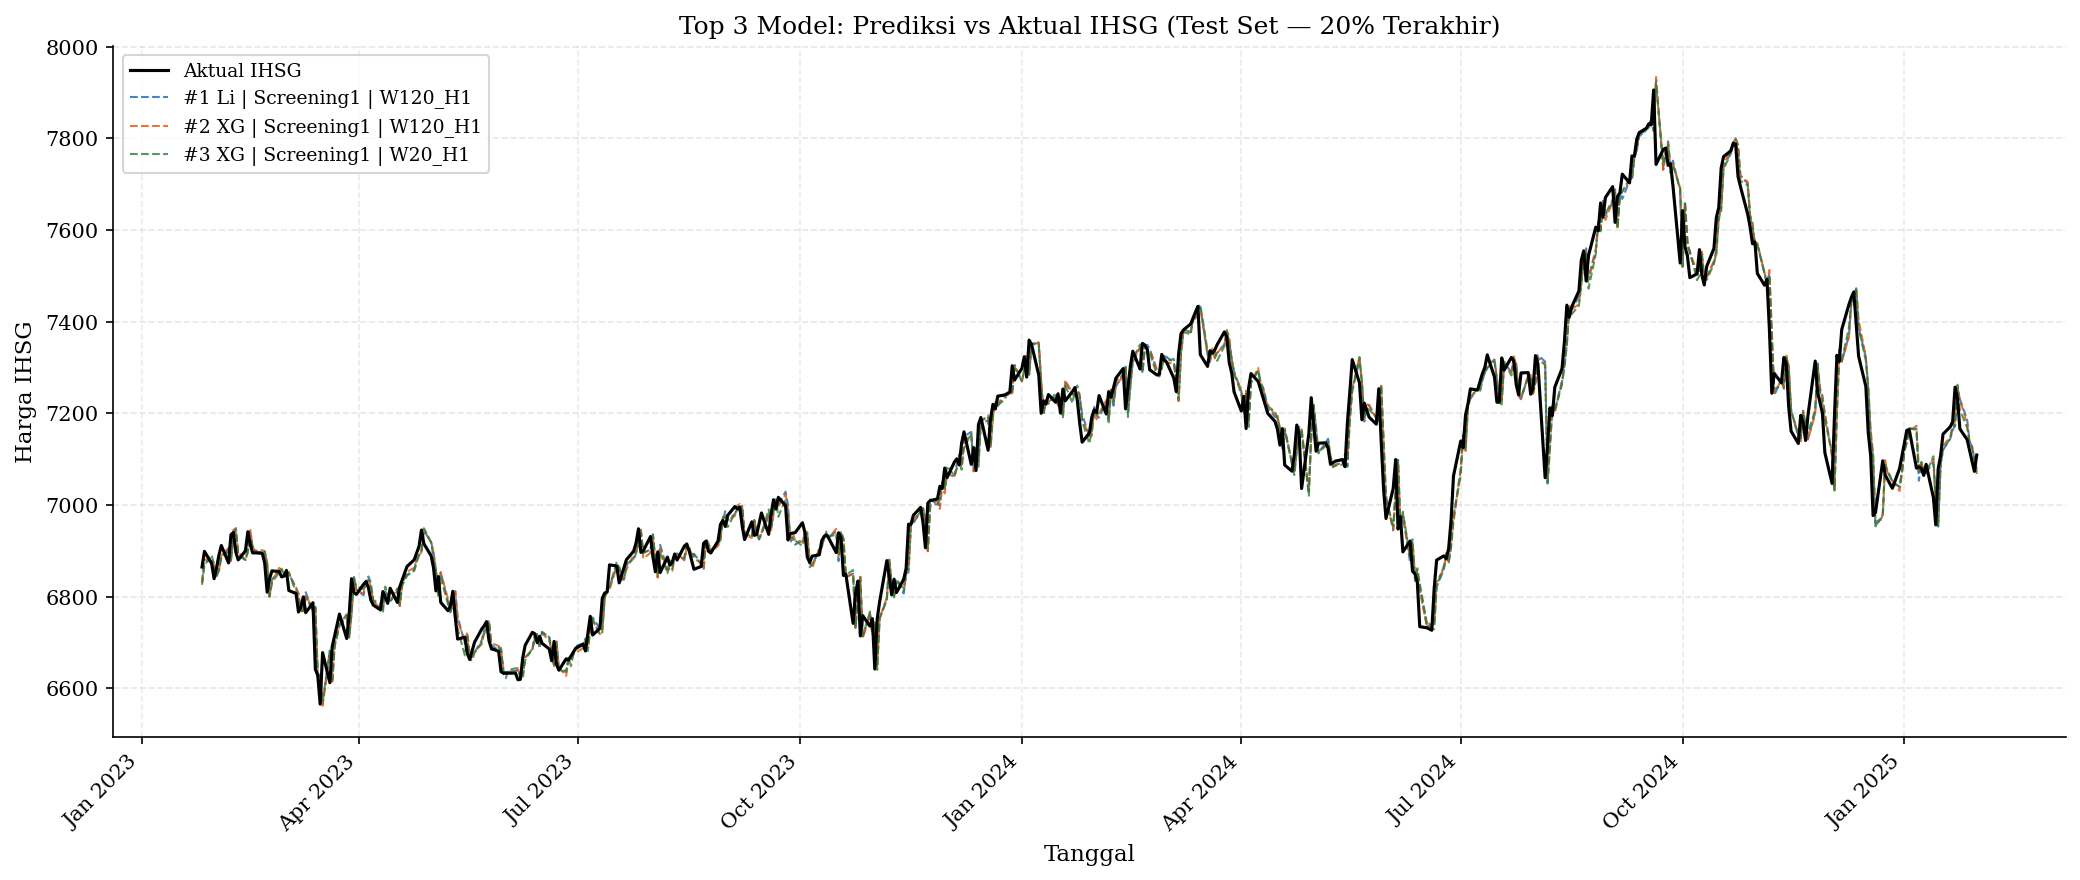

Saved: plot_top3_predictions_combined.png


In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

# Actual (gunakan dates dari model pertama — semua sama)
dates_ts = pd.to_datetime(RESULTS[0]["dates"])
ax.plot(dates_ts, RESULTS[0]["actual"],
        color="black", linewidth=1.5, label="Aktual IHSG", zorder=5)

for res in RESULTS:
    ax.plot(pd.to_datetime(res["dates"]), res["predicted"],
            color=res["color"], linewidth=1, alpha=0.8,
            linestyle="--", label=res["label"])

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45, ha="right")
ax.set_xlabel("Tanggal", fontsize=11)
ax.set_ylabel("Harga IHSG", fontsize=11)
ax.set_title("Top 3 Model: Prediksi vs Aktual IHSG (Test Set — 20% Terakhir)", fontsize=12)
ax.legend(fontsize=9, loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("plot_top3_predictions_combined.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_top3_predictions_combined.png")

## Plot 2 — Subplot Terpisah per Model

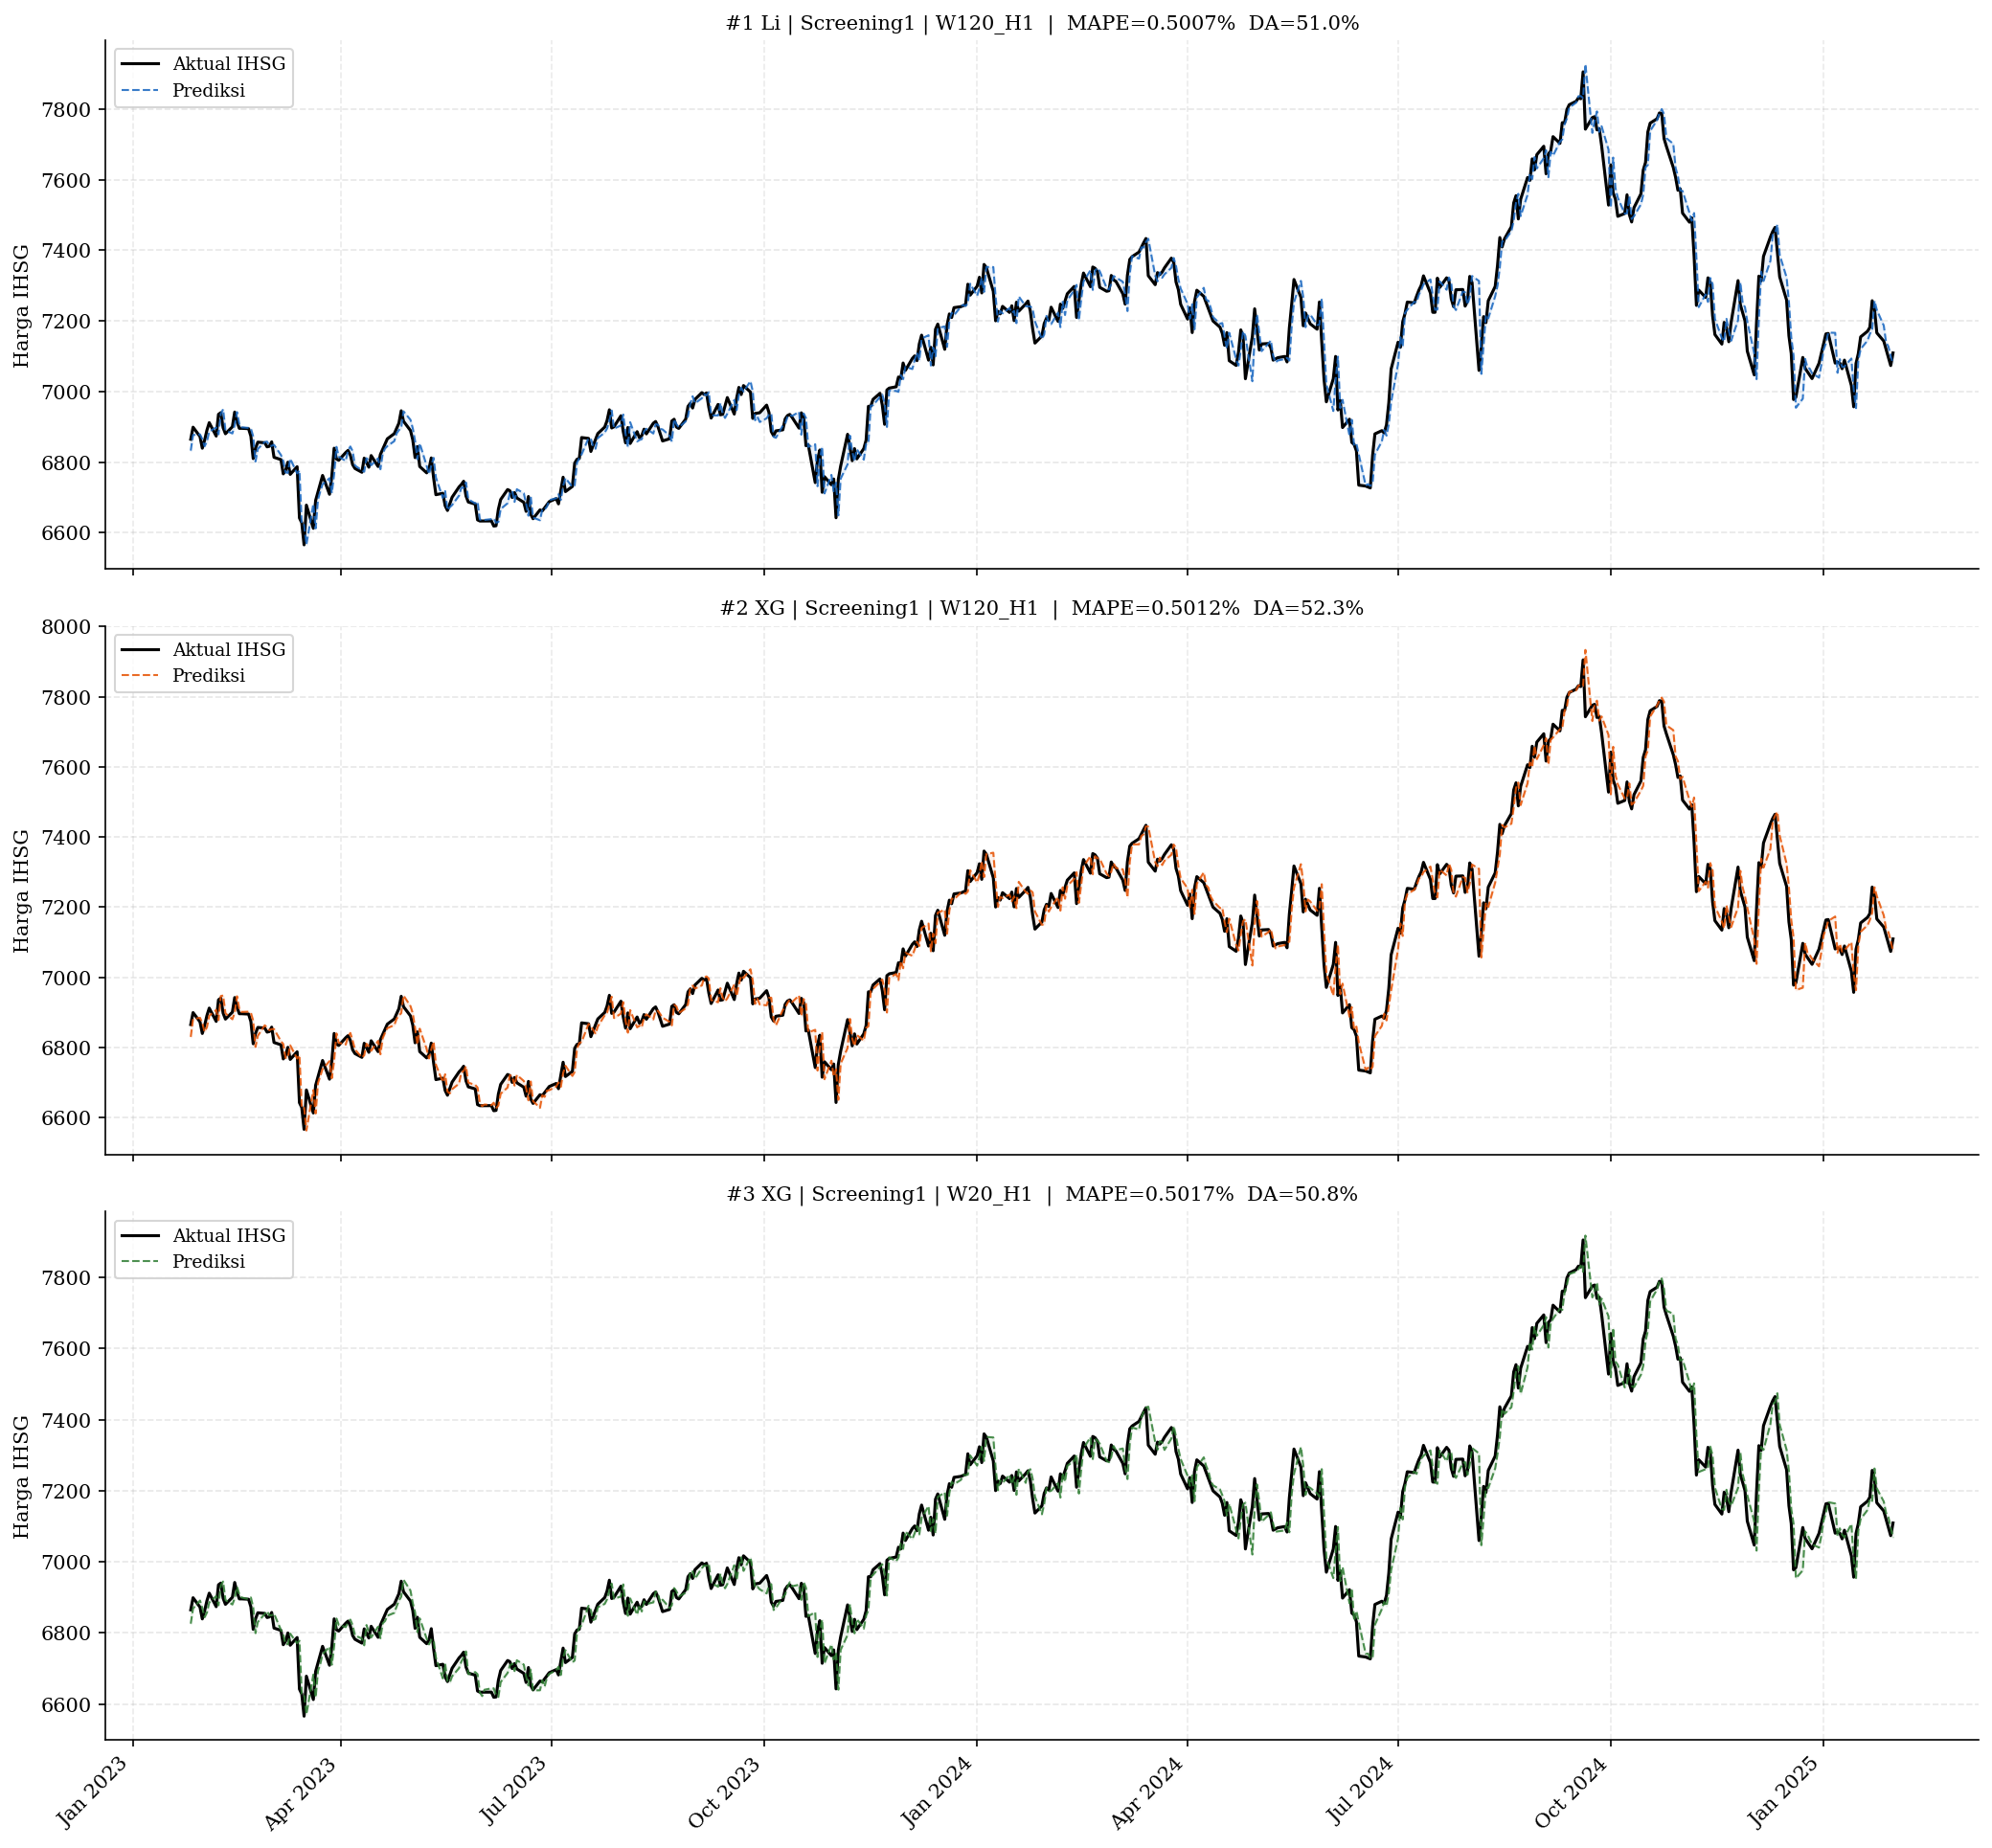

Saved: plot_top3_predictions_subplots.png


In [22]:
fig, axes = plt.subplots(3, 1, figsize=(14, 13), sharex=True)

for ax, res in zip(axes, RESULTS):
    dates_ts = pd.to_datetime(res["dates"])
    actual   = res["actual"]
    pred     = res["predicted"]

    ax.plot(dates_ts, actual, color="black", linewidth=1.5, label="Aktual IHSG")
    ax.plot(dates_ts, pred,   color=res["color"], linewidth=1,
            linestyle="--", alpha=0.85, label=f"Prediksi")

    # Shading error band
    ax.fill_between(dates_ts, actual, pred, alpha=0.08, color=res["color"])

    # Metrik
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    da   = np.mean((np.sign(np.diff(pred)) == np.sign(np.diff(actual)))) * 100
    ax.set_title(f"{res['label']}  |  MAPE={mape:.4f}%  DA={da:.1f}%", fontsize=10)
    ax.set_ylabel("Harga IHSG", fontsize=10)
    ax.legend(fontsize=9, loc="upper left")
    ax.grid(axis="y", alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("plot_top3_predictions_subplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_top3_predictions_subplots.png")

## Plot 3 — Zoom: 3 Bulan Terakhir Test Set

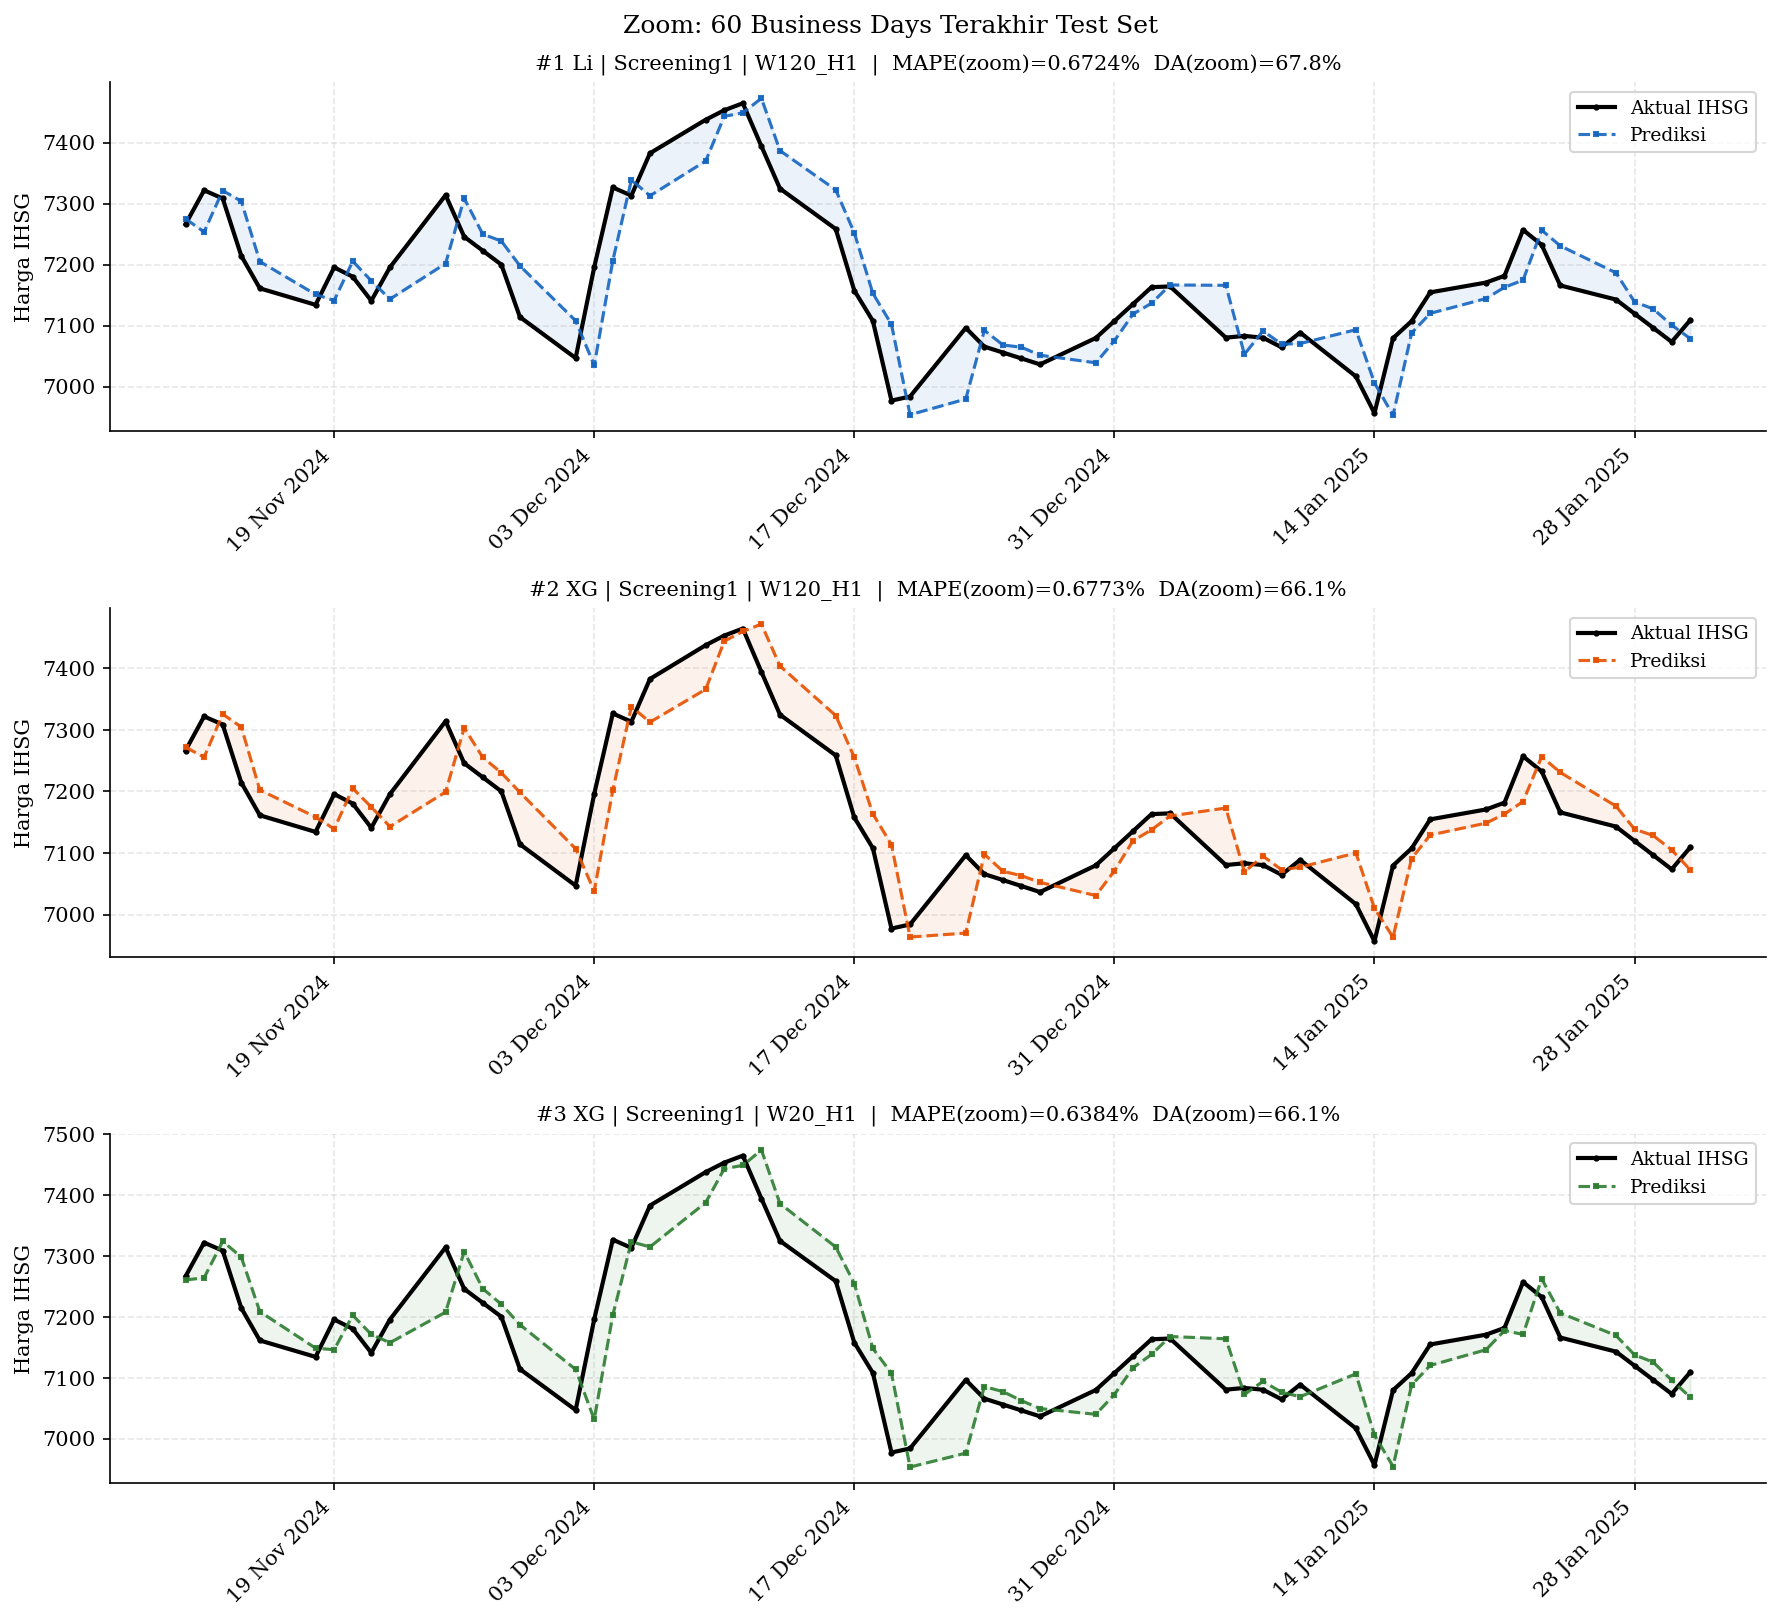

Saved: plot_top3_predictions_zoom.png


In [23]:
# Zoom ke 60 business days terakhir (≈ 3 bulan)
ZOOM = 60

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=False)

for ax, res in zip(axes, RESULTS):
    dates_ts = pd.to_datetime(res["dates"])
    actual   = res["actual"]
    pred     = res["predicted"]

    # Ambil 60 hari terakhir
    d_zoom = dates_ts[-ZOOM:]
    a_zoom = actual[-ZOOM:]
    p_zoom = pred[-ZOOM:]

    ax.plot(d_zoom, a_zoom, color="black", linewidth=2, label="Aktual IHSG", marker="o",
            markersize=2)
    ax.plot(d_zoom, p_zoom, color=res["color"], linewidth=1.5,
            linestyle="--", alpha=0.9, label="Prediksi", marker="s", markersize=2)
    ax.fill_between(d_zoom, a_zoom, p_zoom, alpha=0.08, color=res["color"])

    mape_z = np.mean(np.abs((a_zoom - p_zoom) / a_zoom)) * 100
    da_z   = np.mean((np.sign(np.diff(p_zoom)) == np.sign(np.diff(a_zoom)))) * 100
    ax.set_title(f"{res['label']}  |  MAPE(zoom)={mape_z:.4f}%  DA(zoom)={da_z:.1f}%",
                 fontsize=10)
    ax.set_ylabel("Harga IHSG", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")

plt.suptitle(f"Zoom: {ZOOM} Business Days Terakhir Test Set", fontsize=12)
plt.tight_layout()
plt.savefig("plot_top3_predictions_zoom.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_top3_predictions_zoom.png")

## Plot 4 — Scatter: Aktual vs Prediksi

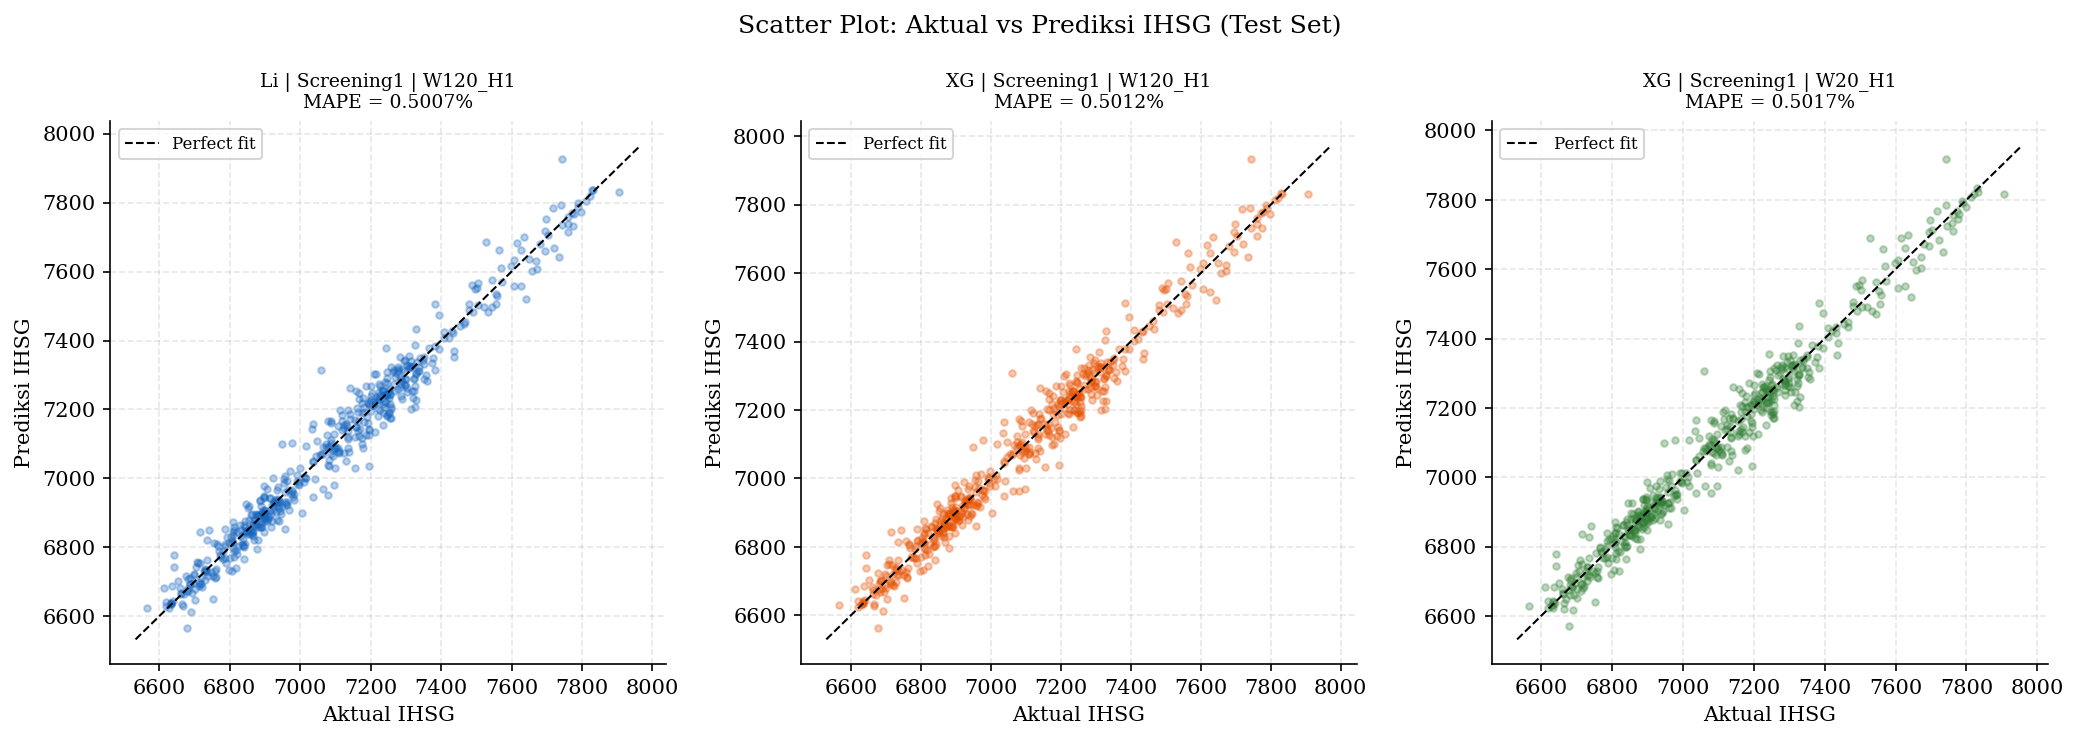

Saved: plot_top3_scatter.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, res in zip(axes, RESULTS):
    actual = res["actual"]
    pred   = res["predicted"]
    mape   = np.mean(np.abs((actual - pred) / actual)) * 100

    ax.scatter(actual, pred, alpha=0.3, s=10, color=res["color"])
    lim_min = min(actual.min(), pred.min()) * 0.995
    lim_max = max(actual.max(), pred.max()) * 1.005
    ax.plot([lim_min, lim_max], [lim_min, lim_max], "k--", linewidth=1, label="Perfect fit")
    ax.set_xlabel("Aktual IHSG", fontsize=10)
    ax.set_ylabel("Prediksi IHSG", fontsize=10)

    cfg = res["cfg"]
    ax.set_title(f"{cfg['Model'][:2]} | {cfg['Covariates']} | W{cfg['Window']}_H{cfg['Horizon']}\n"
                 f"MAPE = {mape:.4f}%", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Scatter Plot: Aktual vs Prediksi IHSG (Test Set)", fontsize=12)
plt.tight_layout()
plt.savefig("plot_top3_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: plot_top3_scatter.png")

## Publication Figure — Best Model: LightGBM + GroupA + W120 + H1

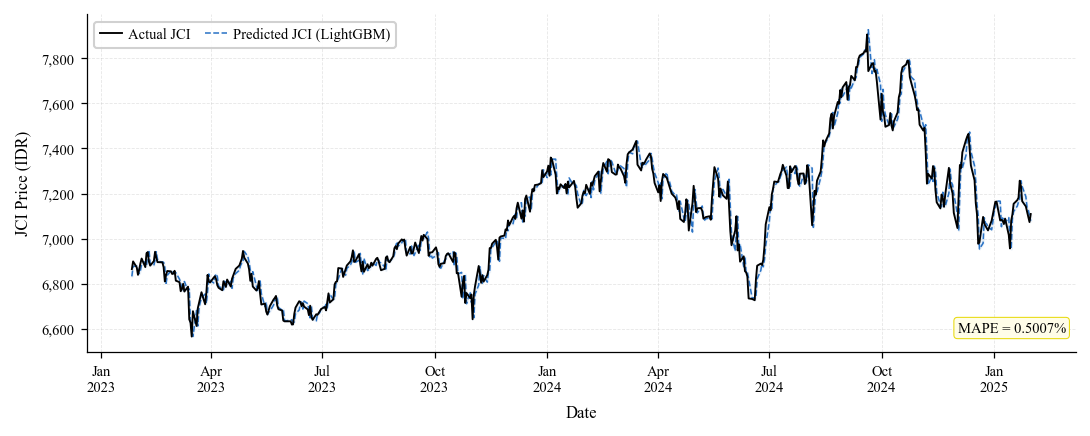

Saved (600 dpi): plot_pub_lightgbm_groupA_W120_H1.png
Saved (preview): plot_pub_lightgbm_groupA_W120_H1_preview.png
Figure size: 7.16" × 2.8"  |  MAPE: 0.5007%

LaTeX usage:  \begin{figure*} ... \includegraphics[width=\textwidth]{...}


In [25]:

# ── IEEE Two-Column Publication Figure ──────────────────────────────────────
# Spans full page width (\begin{figure*} in LaTeX)
# Column width = 3.5in, Full page = 7.16in → use 7.16in wide
# Font: 8pt (matches IEEE body text at print scale)
# DPI: 600 (IEEE final submission requirement)
# ────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

IEEE_WIDTH  = 7.16   # inches — full IEEE page width (two columns)
IEEE_HEIGHT = 2.8    # inches — compact height for two-col spanning figure
IEEE_DPI    = 600    # IEEE requires 600 dpi for raster figures
FONT_PT     = 8      # matches IEEE 8pt body text at print scale

plt.rcParams.update({
    "font.family":        "Times New Roman",
    "font.size":          FONT_PT,
    "axes.titlesize":     FONT_PT,
    "axes.labelsize":     FONT_PT,
    "xtick.labelsize":    FONT_PT - 1,
    "ytick.labelsize":    FONT_PT - 1,
    "legend.fontsize":    FONT_PT - 1,
    "lines.linewidth":    0.9,
    "axes.linewidth":     0.6,
    "xtick.major.width":  0.6,
    "ytick.major.width":  0.6,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "grid.linewidth":     0.4,
    "grid.linestyle":     "--",
    "legend.framealpha":  0.9,
    "legend.edgecolor":   "#cccccc",
})

res    = RESULTS[0]
dates  = pd.to_datetime(res["dates"])
actual = res["actual"]
pred   = res["predicted"]

mape = np.mean(np.abs((actual - pred) / actual)) * 100

fig, ax = plt.subplots(figsize=(IEEE_WIDTH, IEEE_HEIGHT))

ax.plot(dates, actual, color="#000000", linewidth=0.9,
        label="Actual JCI", zorder=5)
ax.plot(dates, pred,   color="#1565C0", linewidth=0.75,
        linestyle="--", alpha=0.9, label="Predicted JCI (LightGBM)", zorder=4)
ax.fill_between(dates, actual, pred, alpha=0.07, color="#1565C0")

ax.set_ylabel("JCI Price (IDR)", labelpad=5)
ax.set_xlabel("Date", labelpad=5)
ax.legend(loc="upper left", ncol=2, columnspacing=1.0,
          handlelength=1.5, handletextpad=0.4)

ax.annotate(
    f"MAPE = {mape:.4f}%",
    xy=(0.99, 0.05), xycoords="axes fraction",
    ha="right", va="bottom", fontsize=FONT_PT - 1,
    bbox=dict(boxstyle="round,pad=0.25", facecolor="#fffde7",
              edgecolor="#e6d800", linewidth=0.5, alpha=0.95)
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.tick_params(axis="both", length=3, pad=3)

plt.tight_layout(pad=0.4)

# Save both 600 dpi (submission) and 150 dpi (preview)
fig.savefig("plot_pub_lightgbm_groupA_W120_H1.png",
            dpi=IEEE_DPI, bbox_inches="tight", facecolor="white")
fig.savefig("plot_pub_lightgbm_groupA_W120_H1_preview.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved (600 dpi): plot_pub_lightgbm_groupA_W120_H1.png")
print(f"Saved (preview): plot_pub_lightgbm_groupA_W120_H1_preview.png")
print(f"Figure size: {IEEE_WIDTH}\" × {IEEE_HEIGHT}\"  |  MAPE: {mape:.4f}%")
print(f"\nLaTeX usage:  \\begin{{figure*}} ... \\includegraphics[width=\\textwidth]{{...}}")
